<a href="https://colab.research.google.com/github/rafaelschaves/exemplo_procsin/blob/master/teste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Explanation:

1.  **`calculate_spectrum(signal, sampling_frequency)` function:**
    *   It takes your `signal` (a NumPy array) and its `sampling_frequency` as input.
    *   `scipy.fft.fft(signal)` computes the Discrete Fourier Transform (DFT) of the signal.
    *   `scipy.fft.fftfreq(N, T)` generates the sample frequencies corresponding to the `fft` output.
    *   We take `[:N//2]` to get only the positive frequency components, as the spectrum is symmetric for real-valued signals.
    *   `2.0/N * np.abs(yf[0:N//2])` calculates the amplitude magnitudes. The factor of `2/N` normalizes the FFT output to represent the actual amplitudes of the sinusoidal components in the signal (excluding the DC component which doesn't get multiplied by 2).


In [ ]:
from scipy.fft import fft, fftfreq

def calculate_spectrum(signal, sampling_frequency):
    """
    Calculates the single-sided amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)
    xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum

    # Calculate the single-sided amplitude spectrum
    # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
    # The factor of 2 is because we are taking only one side of the spectrum
    # and omitting the DC component (yf[0]) which is not multiplied by 2.
    amplitudes = 2.0/N * np.abs(yf[0:N//2])

    return xf, amplitudes

**Example Usage:**
*   A sample signal is created by combining two sine waves (at 50 Hz and 120 Hz) and adding some random noise.
*   The `calculate_spectrum` function is called to get its frequency components and amplitudes.
*   `matplotlib.pyplot` is then used to plot both the original time-domain signal and its calculated frequency spectrum. You should clearly see peaks at 50 Hz and 120 Hz in the spectrum plot, corresponding to the original sine wave frequencies.

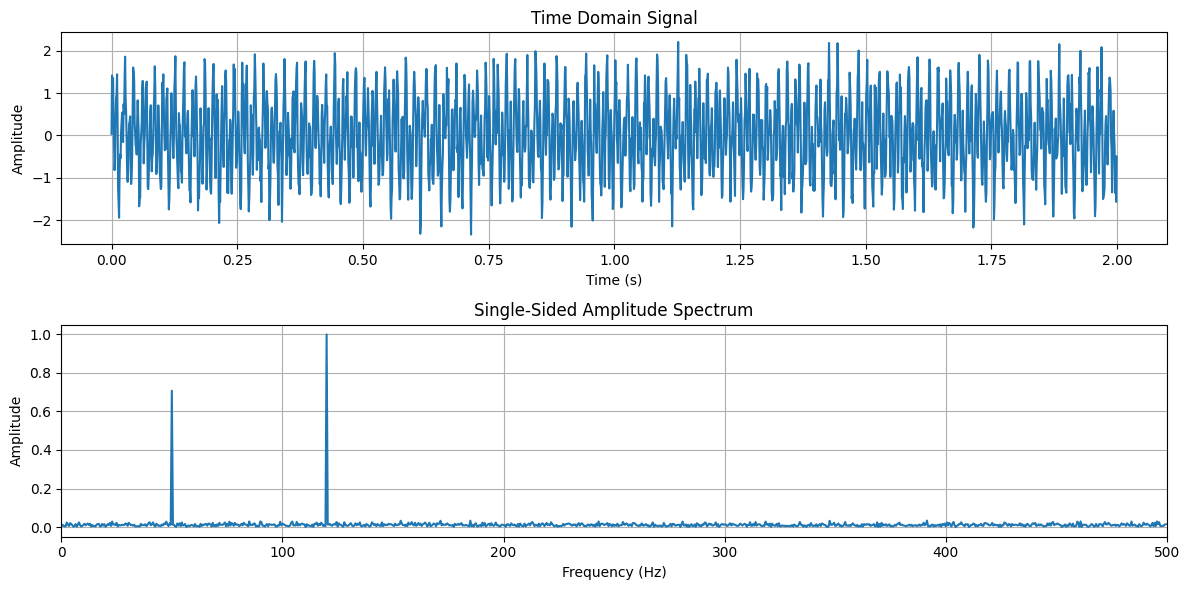

In [ ]:
# --- Example Usage ---

import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a sample signal: A combination of two sine waves
sampling_frequency = 1000 # Hz
duration = 2 # seconds
t = np.linspace(0.0, duration, int(sampling_frequency * duration), endpoint=False)

frequency1 = 50 # Hz
frequency2 = 120 # Hz

signal = 0.7 * np.sin(2 * np.pi * frequency1 * t) + \
         1.0 * np.sin(2 * np.pi * frequency2 * t) + \
         0.3 * np.random.randn(len(t)) # Add some noise

# 2. Calculate the spectrum using the function
frequencies, amplitudes = calculate_spectrum(signal, sampling_frequency)

# 3. Plot the time-domain signal
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title('Time Domain Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# 4. Plot the frequency-domain spectrum
plt.subplot(2, 1, 2)
plt.plot(frequencies, amplitudes)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, sampling_frequency / 2) # Show frequencies up to Nyquist
plt.tight_layout()
plt.show()